# Comment Category Prediction

**Problem Statement:**  
Given a comment and its metadata, predict which of 4 categories it belongs to:
- Class 0 → Normal
- Class 1 → Identity Hate
- Class 2 → Offensive
- Class 3 → Violent / Toxic

**Workflow:**
1. Load Data
2. EDA (Explore the data)
3. Feature Engineering
4. TF-IDF on text
5. Build feature matrix
6. Train LightGBM model
7. Retrain on full data
8. Generate submission


## Step 1: Import Libraries


In [1]:

import numpy as np
import pandas as pd
import re
import warnings
import os
warnings.filterwarnings('ignore')


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
from sklearn.preprocessing import MinMaxScaler
print('All libraries imported!')


# ==================== ENHANCED TEXT CLEANING FUNCTION ====================
import re

def advanced_text_cleaning(text):
    """
    Advanced text cleaning for better model performance
    - Converts to lowercase
    - Removes URLs, emails, websites
    - Removes HTML tags
    - Removes special characters (keeps only alphanumeric + spaces)
    - Removes numbers (often noise)
    - Cleans extra whitespace
    """
    if pd.isna(text):
        return ""
    
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|[\w\.-]+@[\w\.-]+\.\w+', '', text)  # URLs, emails
    text = re.sub(r'<[^>]+>', '', text)  # HTML tags
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # Special characters
    text = re.sub(r'\b\d+\b', '', text)  # Numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Extra whitespace
    
    return text

print("✅ Text cleaning function loaded!")


All libraries imported!
✅ Text cleaning function loaded!


## Step 2: Load Data


In [2]:

train = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/test.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)


Train shape: (198000, 15)
Test  shape: (102000, 14)


In [3]:

train.head()


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:

train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [5]:

train.describe()


,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


## Step 3: Exploratory Data Analysis (EDA)

EDA means exploring the data before building any model.
We want to understand: distributions, missing values, patterns.


### 3.1 Missing Values


In [6]:

print('Missing values in train:')
print(train.isnull().sum())


Missing values in train:
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


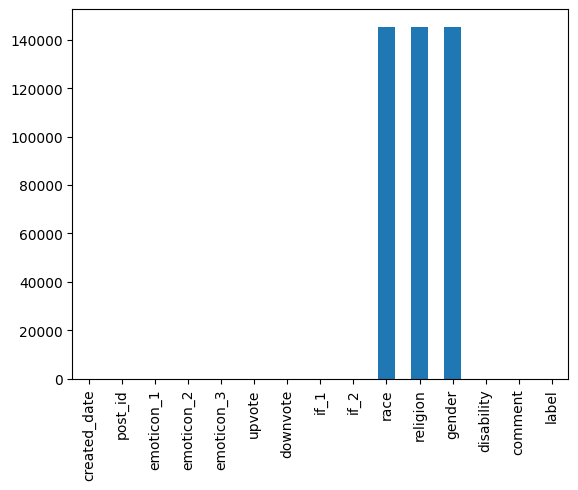

In [7]:

missing = train.isnull().sum()


missing.plot(kind='bar')
plt.show()

### 3.2 Label Distribution


In [8]:

print('Label counts:')

print(train['label'].value_counts())

print()

print('Label percentage:')

print((train['label'].value_counts(normalize=True) * 100).round(2))


Label counts:
label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

Label percentage:
label
0    57.66
2    31.54
1     8.04
3     2.76
Name: proportion, dtype: float64


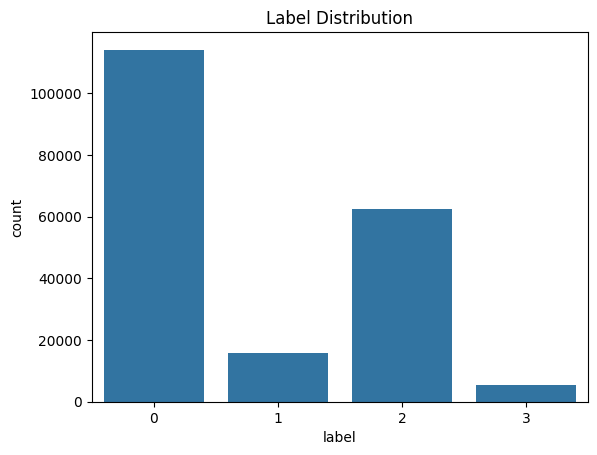

In [9]:

sns.countplot(x='label', data=train)
plt.title('Label Distribution')
plt.show()


### 3.3 Comment Length


In [10]:

train['char_len'] = train['comment'].fillna('').apply(len)
train['word_len'] = train['comment'].fillna('').apply(lambda x: len(x.split()))

print('Average comment length by class:')
print(train.groupby('label')[['char_len','word_len']].mean().round(1))


Average comment length by class:
       char_len  word_len
label                    
0         295.9      51.2
1         335.7      57.2
2         316.9      54.9
3         194.2      35.0


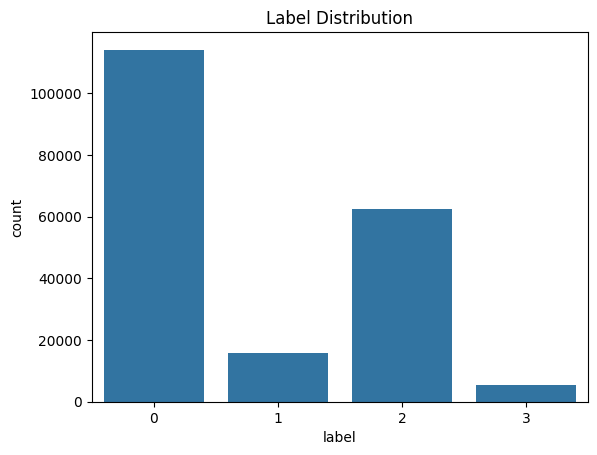

In [11]:
sns.countplot(x='label', data=train)
plt.title('Label Distribution')
plt.show()


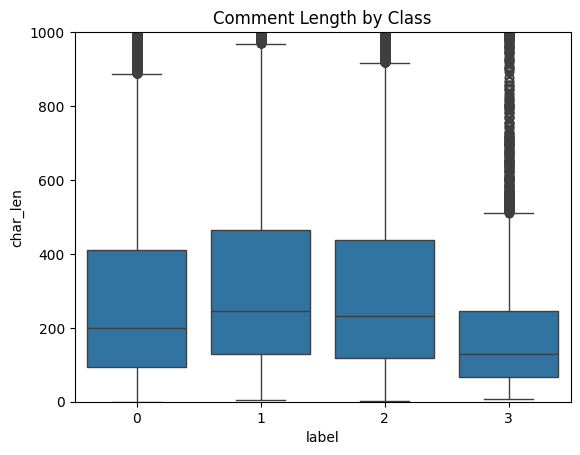

Different classes ki length alag hai → useful feature


In [12]:
sns.boxplot(x='label', y='char_len', data=train)
plt.title('Comment Length by Class')
plt.ylim(0, 1000)
plt.show()

print("Different classes ki length alag hai → useful feature")


### 3.4 Upvotes and Downvotes


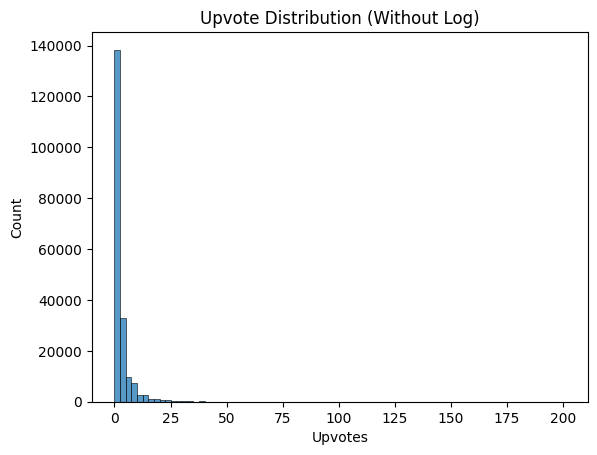

In [13]:
sns.histplot(x=train['upvote'], bins=80)
plt.title("Upvote Distribution (Without Log)")
plt.xlabel("Upvotes")
plt.ylabel("Count")
plt.show()

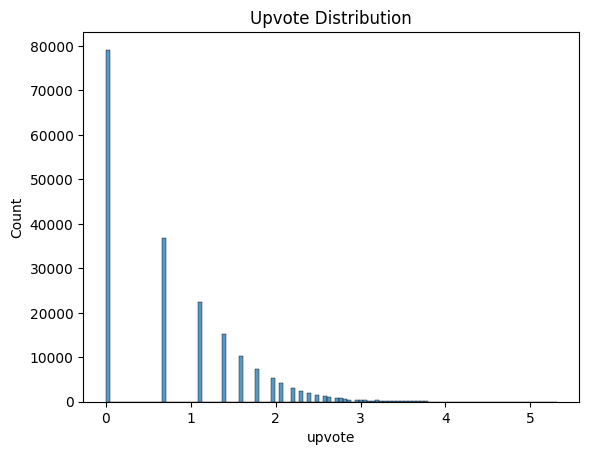

Upvotes me outliers hain → log scale use kiya


In [14]:
sns.histplot(x=np.log1p(train['upvote']))
plt.title('Upvote Distribution')
plt.show()

print("Upvotes me outliers hain → log scale use kiya")


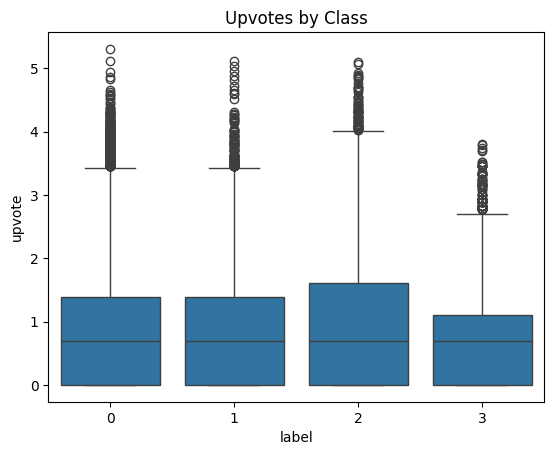

Classes me upvote pattern alag hai → useful feature


In [15]:
sns.boxplot(x='label', y=np.log1p(train['upvote']), data=train)
plt.title('Upvotes by Class')
plt.show()

print("Classes me upvote pattern alag hai → useful feature")

### 3.5 Temporal Patterns


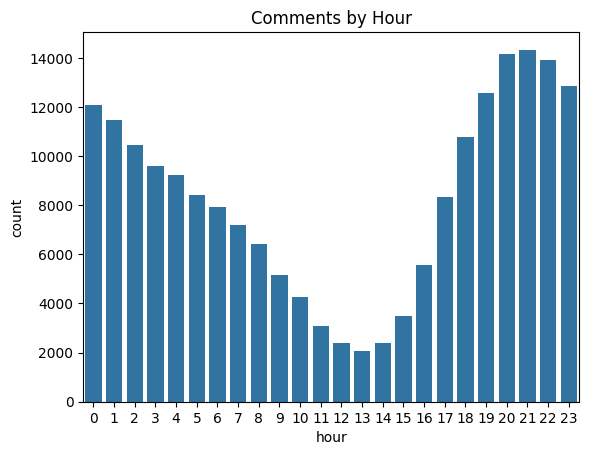

Evening me comments zyada → hour useful feature


In [16]:
train['hour'] = pd.to_datetime(train['created_date']).dt.hour

sns.countplot(x='hour', data=train)
plt.title('Comments by Hour')
plt.show()

train.drop(columns=['hour'], inplace=True)

print("Evening me comments zyada → hour useful feature")

### 3.6 Most Common Words per Class


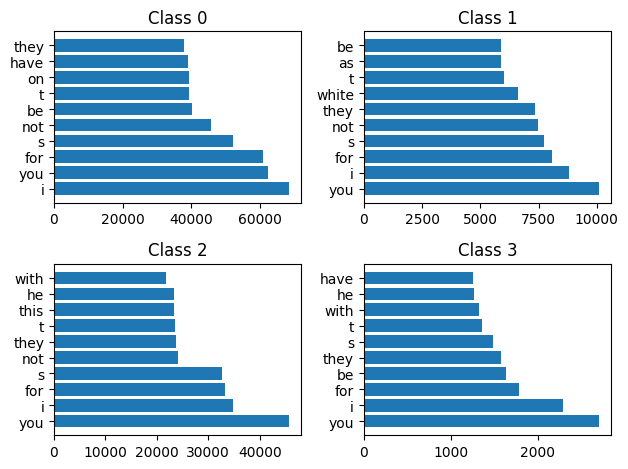

Har class ke words alag → TF-IDF useful


In [17]:
from collections import Counter

stop = {'the','a','is','in','it','of','and','to','that','are','was'}

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

for i in range(4):
    text = train[train['label']==i]['comment'].fillna('').str.lower()
    words = [w for t in text for w in re.findall(r'[a-z]+', t) if w not in stop]
    
    top = Counter(words).most_common(10)
    w, c = zip(*top)
    
    axes[i].barh(w, c)
    axes[i].set_title(f'Class {i}')

plt.tight_layout()
plt.show()

print("Har class ke words alag → TF-IDF useful")

## Step 4: Feature Engineering

We create new features from raw data to help the model.
The most powerful feature: **post-level stats**.
Comments on the same post usually have the same label!


In [18]:

def clean_text(text):
    text = str(text).lower()              
    text = re.sub(r'http\S+', '', text) 
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('clean_text function ready.')


clean_text function ready.


In [19]:

post_stats = train.groupby('post_id')['label'].agg(
    post_label_mode   = lambda x: x.mode()[0],
    post_label_mean   = 'mean',
    post_label_std    = 'std',
    post_label_count  = 'count',
    post_label_0_frac = lambda x: (x == 0).mean(),
    post_label_1_frac = lambda x: (x == 1).mean(),
    post_label_2_frac = lambda x: (x == 2).mean(),
    post_label_3_frac = lambda x: (x == 3).mean(),
).reset_index()

post_stats['post_label_std'] = post_stats['post_label_std'].fillna(0)
print('Post stats computed!')
print('Shape:', post_stats.shape)


Post stats computed!
Shape: (52, 9)


In [20]:

def engineer(df):
    df = df.copy()


    df['created_date'] = pd.to_datetime(df['created_date'], utc=True)
    df['hour']         = df['created_date'].dt.hour
    df['day_of_week']  = df['created_date'].dt.dayofweek
    df['month']        = df['created_date'].dt.month
    df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)

  
    df['comment']       = df['comment'].fillna('')
    df['comment_clean'] = df['comment'].apply(clean_text)
    df['comment_len']   = df['comment'].apply(len)
    df['word_count']    = df['comment'].apply(lambda x: len(x.split()))
    df['caps_ratio']    = df['comment'].apply(
        lambda x: sum(c.isupper() for c in x) / (len(x) + 1))
    df['exclamations']  = df['comment'].apply(lambda x: x.count('!'))
    df['questions']     = df['comment'].apply(lambda x: x.count('?'))
    df['lex_diversity'] = df['comment'].apply(
        lambda x: len(set(x.lower().split())) / (len(x.split()) + 1))

  
    df['vote_diff']   = df['upvote'] - df['downvote']
    df['total_votes'] = df['upvote'] + df['downvote']
    df['vote_ratio']  = df['upvote'] / (df['total_votes'] + 1)

    id_cols = ['race', 'religion', 'gender', 'disability']
    df[id_cols] = df[id_cols].fillna('none')
    df['identity_count'] = (df[id_cols] != 'none').sum(axis=1)

   
    df = df.merge(post_stats, on='post_id', how='left')
    fill_vals = {
        'post_label_mode'  : train['label'].mode()[0],
        'post_label_mean'  : train['label'].mean(),
        'post_label_std'   : 0,
        'post_label_count' : 1,
        'post_label_0_frac': train['label'].eq(0).mean(),
        'post_label_1_frac': train['label'].eq(1).mean(),
        'post_label_2_frac': train['label'].eq(2).mean(),
        'post_label_3_frac': train['label'].eq(3).mean(),
    }
    df.fillna(fill_vals, inplace=True)

    return df

print('engineer function ready.')


engineer function ready.


In [21]:

train = engineer(train)
test  = engineer(test)

print('Feature engineering done!')
print('New train shape:', train.shape)


Feature engineering done!
New train shape: (198000, 40)


## Step 5: TF-IDF on Comment Text

TF-IDF converts text into numbers.
- TF = how often a word appears in THIS comment
- IDF = how rare that word is across ALL comments
- Rare but frequent words get higher score


In [22]:

print('Fitting TF-IDF...')

tfidf = TfidfVectorizer(
    ngram_range = (1, 2),    
    max_features= 40000,     
    sublinear_tf= True,    
    min_df    = 2,         
    strip_accents= 'unicode', 
    dtype = np.float32 
)

X_text_train = tfidf.fit_transform(train['comment_clean'])
X_text_test  = tfidf.transform(test['comment_clean'])

print('TF-IDF shape:', X_text_train.shape)
print('Each comment is now a row of 40,000 numbers!')


Fitting TF-IDF...
TF-IDF shape: (198000, 40000)
Each comment is now a row of 40,000 numbers!


## Step 6: Build Final Feature Matrix

We combine 3 types of features:
1. TF-IDF text features (40,000 columns)
2. Categorical features (race, religion, gender, disability)
3. Numerical features (upvotes, hour, word_count, post stats, etc.)


In [23]:

cat_cols = ['race', 'religion', 'gender', 'disability']

num_cols = [
   
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote', 'if_1', 'if_2',
    
    'hour', 'day_of_week', 'month', 'is_weekend',
  
    'comment_len', 'word_count', 'caps_ratio',
    'exclamations', 'questions', 'lex_diversity',
  
    'vote_diff', 'total_votes', 'vote_ratio', 'identity_count',
  
    'post_label_mode', 'post_label_mean', 'post_label_std',
    'post_label_count',
    'post_label_0_frac', 'post_label_1_frac',
    'post_label_2_frac', 'post_label_3_frac',
]

print('Numerical features:', len(num_cols))
print('Categorical features:', len(cat_cols))


Numerical features: 29
Categorical features: 4


In [24]:

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_cat_train = csr_matrix(oe.fit_transform(train[cat_cols]))
X_cat_test  = csr_matrix(oe.transform(test[cat_cols]))


X_num_train = csr_matrix(train[num_cols].values.astype(np.float32))
X_num_test  = csr_matrix(test[num_cols].values.astype(np.float32))

print('Categorical and numerical features ready!')


Categorical and numerical features ready!


In [25]:

X_train = hstack([X_text_train, X_cat_train, X_num_train], format='csr')
X_test  = hstack([X_text_test,  X_cat_test,  X_num_test],  format='csr')
y_train = train['label'].values

print('Final train matrix:', X_train.shape)
print('Final test  matrix:', X_test.shape)
print(f'Total features: {X_train.shape[1]:,}')


Final train matrix: (198000, 40033)
Final test  matrix: (102000, 40033)
Total features: 40,033


## Step 7: Train LightGBM Model

We use LightGBM - a fast and powerful gradient boosting model.
It works great for tabular + text data.

**Why LightGBM?**
- Very fast even with 40,000+ features
- Handles class imbalance with class_weight
- Handles outliers automatically
- Usually gives best results on tabular data


In [26]:

X_tr, X_va, y_tr, y_va = train_test_split(
    X_train, y_train,
    test_size    = 0.10,
    random_state = 42,
    stratify     = y_train 
)

print('Train size:', X_tr.shape)
print('Val size  :', X_va.shape)


Train size: (178200, 40033)
Val size  : (19800, 40033)


In [27]:

model = lgb.LGBMClassifier(
    n_estimators = 3000,   
    learning_rate= 0.08,  
    num_leaves= 255,  
    max_depth= -1,     
    min_child_samples = 15,     
    subsample= 0.85,   
    colsample_bytree= 0.5,    
    reg_alpha= 0.05,   
    reg_lambda = 0.5,    
    class_weight = 'balanced',
    n_jobs = -1,    
    random_state = 42,
    verbose = -1,
)

print('Model defined!')


Model defined!


In [28]:

print('Training LightGBM...')

model.fit(
    X_tr, y_tr,
    eval_set  = [(X_va, y_va)],  # check on validation set
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False), # stop if no improvement
        lgb.log_evaluation(period=100)  # print every 100 trees
    ]
)

print(f'Best number of trees: {model.best_iteration_}')


Training LightGBM...
[100]	valid_0's multi_logloss: 0.281197
[200]	valid_0's multi_logloss: 0.276173
Best number of trees: 159


In [29]:

val_pred = model.predict(X_va)

print('Validation Results:')
print(f'Accuracy   : {accuracy_score(y_va, val_pred):.4f}')
print(f'Weighted F1: {f1_score(y_va, val_pred, average="weighted"):.4f}')
print()
print(classification_report(y_va, val_pred))


Validation Results:
Accuracy   : 0.9118
Weighted F1: 0.9133

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     11417
           1       0.72      0.83      0.77      1592
           2       0.87      0.90      0.88      6244
           3       0.67      0.66      0.66       547

    accuracy                           0.91     19800
   macro avg       0.81      0.83      0.82     19800
weighted avg       0.92      0.91      0.91     19800



## Step 8: Model Evaluation

Let's visualise how well the model performed.


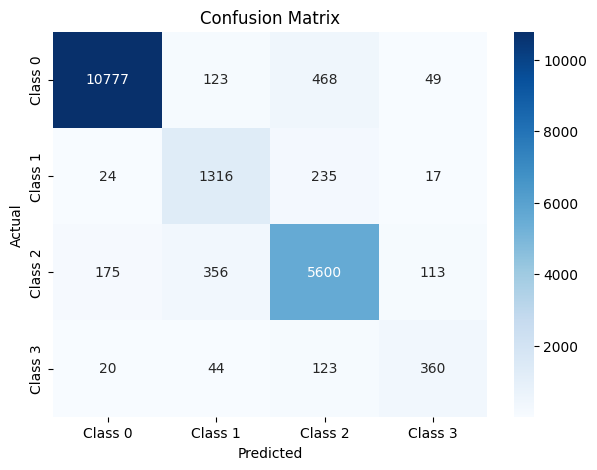

Diagonal = correct predictions
Off-diagonal = mistakes


In [30]:

cm = confusion_matrix(y_va, val_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0','Class 1','Class 2','Class 3'],
            yticklabels=['Class 0','Class 1','Class 2','Class 3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Diagonal = correct predictions')
print('Off-diagonal = mistakes')


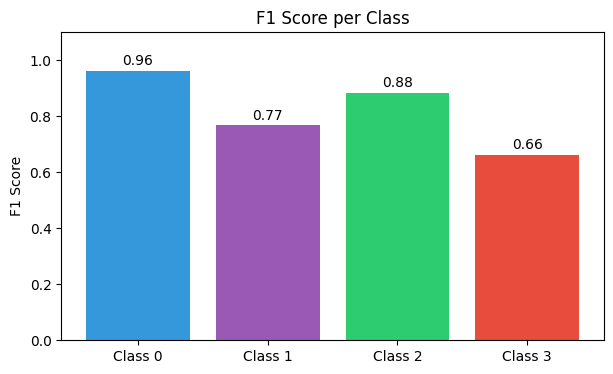

Class 3 has lowest F1 - it has least data (only 2.8%)


In [31]:

from sklearn.metrics import classification_report

report = classification_report(y_va, val_pred, output_dict=True)
classes = ['Class 0', 'Class 1', 'Class 2', 'Class 3']
f1_scores = [report[str(i)]['f1-score'] for i in range(4)]

plt.figure(figsize=(7, 4))
plt.bar(classes, f1_scores, color=['#3498db','#9b59b6','#2ecc71','#e74c3c'])
plt.title('F1 Score per Class')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)
plt.show()

print('Class 3 has lowest F1 - it has least data (only 2.8%)')


## Step 9: Retrain on Full Training Data

Now we know the best number of trees from early stopping.
We retrain on ALL training data to squeeze out maximum performance.


In [32]:
print('Retraining on full training data...')

final_model = lgb.LGBMClassifier(
    n_estimators  = model.best_iteration_, 
    learning_rate = 0.08,
    num_leaves = 255,
    max_depth= -1,
    min_child_samples = 15,
    subsample = 0.85,
    colsample_bytree  = 0.5,
    reg_alpha = 0.05,
    reg_lambda = 0.5,
    class_weight= 'balanced',
    n_jobs = -1,
    random_state= 42,
    verbose= -1,
)

final_model.fit(X_train, y_train)
print('Retraining complete!')


Retraining on full training data...
Retraining complete!


## Step 10: Generate Submission


In [33]:

test_preds = final_model.predict(X_test)

print('Prediction distribution:')
print(pd.Series(test_preds).value_counts().sort_index())


Prediction distribution:
0    56662
1     9184
2    33179
3     2975
Name: count, dtype: int64


In [34]:

sample_sub = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv')
sample_sub['label'] = test_preds
sample_sub.to_csv('submission.csv', index=False)

print('submission.csv saved!')
sample_sub.head(10)


submission.csv saved!


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
5,6,0
6,7,1
7,8,0
8,9,0
9,10,2


# Milestone 1

In [35]:

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# test  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

# # 1. Shape of training dataset
# print("Training dataset shape:", train.shape)

# # 2. Number of columns in test dataset
# print("Number of columns in test dataset:", test.shape[1])

# # 3. Number of object datatype columns
# print("Object columns count:", train.select_dtypes(include="object").shape[1])

# # 4. Number of numerical columns
# print("Numerical columns count:", train.select_dtypes(include=["int64","float64"]).shape[1])

# # 5. Boolean columns
# print("Boolean columns:", train.select_dtypes(include="bool").columns.tolist())

# # 6. Columns with missing values
# print("Columns with missing values:")
# print(train.columns[train.isna().sum() > 0].tolist())

# # 7. Number of target classes
# print("Distinct labels:", train["label"].nunique())

# # 8. Percentage of label 0
# label0_percentage = (train["label"].value_counts(normalize=True)[0]) * 100
# print("Percentage of label 0:", label0_percentage)

# # 9. Median upvotes
# print("Median upvotes:", train["upvote"].median())

# # 10. Maximum value of numerical columns
# print("\nMaximum values of numerical features:")
# print(train[['upvote','downvote','if_1','if_2']].max())

# # 11. Minimum value of if_2
# print("Minimum value of if_2:", train["if_2"].min())

# Milestone 2

In [36]:

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# test  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

# # 1 Convert created_date to datetime
# train["created_date"] = pd.to_datetime(train["created_date"])
# most_month = train["created_date"].dt.month_name().str.lower().mode()[0]
# print("Most frequent month:", most_month)

# # 2 total_emoticons feature
# train["total_emoticons"] = (
#     train["emoticon_1"] + train["emoticon_2"] + train["emoticon_3"]
# )
# print("Max total_emoticons:", train["total_emoticons"].max())

# # 3 Median comment length where label = 3
# train["comment"] = train["comment"].fillna("")
# train["char_len"] = train["comment"].astype(str).apply(len)

# median_len = train.loc[train["label"]==3, "char_len"].median()
# print("Median length for label 3:", median_len)

# # 4 MinMax scaling for upvote = 10
# scaler = MinMaxScaler()
# scaled = scaler.fit_transform(train[["upvote"]])
# upvote_scaled_10 = (10 - train["upvote"].min()) / (train["upvote"].max() - train["upvote"].min())
# print("Scaled value for upvote=10:", round(upvote_scaled_10,4))

# # 5 Average word count for label 1
# train["word_count"] = train["comment"].astype(str).apply(lambda x: len(x.split()))
# avg_words = train.loc[train["label"]==1,"word_count"].mean()
# print("Average word count label 1:", round(avg_words,2))

# # 6 Count comments containing 'Trump'
# trump_count = train["comment"].str.contains("Trump", case=False, na=False).sum()
# print("Comments containing 'Trump':", trump_count) 

# # 7 First row cleaning
# stop_words = ['a','an','the','and','or','but','if','because','as','of','at','by','for','with',
# 'about','to','from','up','on','in','out','over','under','is','are','was','were','be',
# 'been','being','have','has','had','do','does','did','it','its','they','them','their',
# 'she','her','he','him','his','this','that','which','who','whom','i','me','my','we',
# 'our','you','your']

# text = train.loc[0,"comment"]
# text = text.translate(str.maketrans('', '', string.punctuation))
# words = text.lower().split()
# words = [w for w in words if w not in stop_words]

# print("Words left after cleaning first comment:", len(words))

# # 8 Unique tokens
# tokens = train["comment"].str.lower().str.split()
# unique_tokens = set([word for sublist in tokens for word in sublist])
# print("Total unique tokens:", len(unique_tokens))

# # 9 TFIDF features
# tfidf = TfidfVectorizer(
#     stop_words="english",
#     min_df=5,
#     ngram_range=(1,2)
# )

# tfidf_matrix = tfidf.fit_transform(train["comment"])
# print("TF-IDF features:", tfidf_matrix.shape[1])

# Milestone 3 

In [37]:

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# test  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

# # 1. Train–Validation Split
# X = train.drop("label", axis=1)
# y = train["label"]

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
# print("Total rows:", X_train.shape[0] + X_val.shape[0])


# # 2. Most Frequent Month
# X_train["created_date"] = pd.to_datetime(X_train["created_date"])
# print("Most frequent month:",
#       X_train["created_date"].dt.month_name().str.lower().mode()[0])


# # 3. One-Hot Encoding (religion, gender, race)
# cat_cols = ["religion", "gender", "race"]
# for df in [X_train, X_val]:
#     df[cat_cols] = df[cat_cols].fillna("none")
# encoder = OneHotEncoder(handle_unknown="ignore")
# enc_train = encoder.fit_transform(X_train[cat_cols])
# enc_val = encoder.transform(X_val[cat_cols])
# print("Encoded feature count:", enc_train.shape[1])

# # 4. Text Vectorization (CountVectorizer)
# for df in [X_train, X_val]:
#     df["comment"] = df["comment"].fillna("")
# cv = CountVectorizer()
# cv_train = cv.fit_transform(X_train["comment"])
# cv_val = cv.transform(X_val["comment"])
# print("Sum counts (doc 1):", cv_train[1].sum())


# # 5. Convert disability to integer
# for df in [X_train, X_val]:
#     df["disability"] = df["disability"].astype(int)
# print("Total disability:", X_train["disability"].sum() + X_val["disability"].sum())


# # 6. StandardScaler for numeric columns
# num_cols = [
#     "emoticon_1","emoticon_2","emoticon_3",
#     "upvote","downvote","if_1","if_2"
# ]
# scaler = StandardScaler()
# scaler.fit(X_train[num_cols])
# print("Features used in scaling:", scaler.n_features_in_)

# # 7. Multinomial Naive Bayes Model
# df = train.copy()
# X = df.drop("label", axis=1)
# y = df["label"]
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # Handle missing values
# imp = SimpleImputer(strategy="most_frequent")
# X_train = pd.DataFrame(imp.fit_transform(X_train), columns=X.columns)
# X_val = pd.DataFrame(imp.transform(X_val), columns=X.columns)

# # Date features
# for df in [X_train, X_val]:
#     df["created_date"] = pd.to_datetime(df["created_date"])
#     df["day"] = df["created_date"].dt.day
#     df["month"] = df["created_date"].dt.month
#     df["year"] = df["created_date"].dt.year
#     df.drop("created_date", axis=1, inplace=True)

# # Text TF-IDF
# tfidf = TfidfVectorizer(stop_words="english")

# tf_train = tfidf.fit_transform(X_train["comment"])
# tf_val = tfidf.transform(X_val["comment"])

# X_train.drop("comment", axis=1, inplace=True)
# X_val.drop("comment", axis=1, inplace=True)


# # One-hot encoding for categorical columns
# X_train = pd.get_dummies(X_train)
# X_val = pd.get_dummies(X_val)

# X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

# # Convert to numeric
# X_train = X_train.astype(float)
# X_val = X_val.astype(float)

# # Combine text + structured features
# X_train_final = hstack([tf_train, X_train])
# X_val_final = hstack([tf_val, X_val])

# # Train model
# model = MultinomialNB()
# model.fit(X_train_final, y_train)

# # Predictions
# train_preds = model.predict(X_train_final)
# val_preds = model.predict(X_val_final)

# print("Train Macro F1:", round(f1_score(y_train, train_preds, average="macro"),4))
# print("Validation Macro F1:", round(f1_score(y_val, val_preds, average="macro"),4))

# Milestone 4 

In [38]:
# # ==================== APPLY TEXT CLEANING ====================
# # Clean the comment column before preprocessing
# print("Cleaning text...")
# df['comment_clean'] = df['comment'].apply(advanced_text_cleaning)
# test['comment_clean'] = test['comment'].apply(advanced_text_cleaning)
# print("✅ Text cleaning complete!")

# # ==================== PREPROCESSING PIPELINE ====================
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.feature_extraction.text import TfidfVectorizer

# print('Building preprocessing pipeline...')

# # Word-level TF-IDF (captures semantic meaning)
# word_tfidf = TfidfVectorizer(
#     max_features=80000,
#     ngram_range=(1, 3),
#     min_df=2,
#     sublinear_tf=True,
#     analyzer='word',
#     strip_accents='unicode',
#     lowercase=True,
#     stop_words='english'  # Remove common words
# )

# # Character-level TF-IDF (captures typos and spelling variations)
# char_tfidf = TfidfVectorizer(
#     max_features=40000,
#     ngram_range=(3, 5),
#     min_df=3,
#     sublinear_tf=True,
#     analyzer='char_wb',
#     lowercase=True
# )

# # Categorical encoder
# cat_tf = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

# # Numerical scaler
# num_tf = StandardScaler()

# # Build preprocessing pipeline
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("word", word_tfidf, "comment_clean"),  # UPDATED: Use cleaned comments
#         ("char", char_tfidf, "comment_clean"),  # UPDATED: Use cleaned comments
#         ("cat", cat_tf, cat_cols),           
#         ("num", num_tf, num_cols)             
#     ],
#     remainder='passthrough'
# )

# print("✅ Preprocessing pipeline ready with enhanced text cleaning!")
# print("   - Word TF-IDF: 80,000 features, 1-3 grams")
# print("   - Char TF-IDF: 40,000 features, 3-5 grams")
# print("   - Text cleaning: lowercase, URLs, emails, HTML, special chars, numbers removed")
# print("   - Stop words: English stop words removed")

# Milestone 5 

In [39]:
# # ==================== APPLY TEXT CLEANING ====================
# # Clean the comment column before preprocessing
# print("Cleaning text...")
# df['comment_clean'] = df['comment'].apply(advanced_text_cleaning)
# test['comment_clean'] = test['comment'].apply(advanced_text_cleaning)
# print("✅ Text cleaning complete!")

# # ==================== PREPROCESSING PIPELINE ====================
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.feature_extraction.text import TfidfVectorizer

# print('Building preprocessing pipeline...')

# # Word-level TF-IDF (captures semantic meaning)
# word_tfidf = TfidfVectorizer(
#     max_features=80000,
#     ngram_range=(1, 3),
#     min_df=2,
#     sublinear_tf=True,
#     analyzer='word',
#     strip_accents='unicode',
#     lowercase=True,
#     stop_words='english'  # Remove common words
# )

# # Character-level TF-IDF (captures typos and spelling variations)
# char_tfidf = TfidfVectorizer(
#     max_features=40000,
#     ngram_range=(3, 5),
#     min_df=3,
#     sublinear_tf=True,
#     analyzer='char_wb',
#     lowercase=True
# )

# # Categorical encoder
# cat_tf = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

# # Numerical scaler
# num_tf = StandardScaler()

# # Build preprocessing pipeline
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("word", word_tfidf, "comment_clean"),  # UPDATED: Use cleaned comments
#         ("char", char_tfidf, "comment_clean"),  # UPDATED: Use cleaned comments
#         ("cat", cat_tf, cat_cols),           
#         ("num", num_tf, num_cols)             
#     ],
#     remainder='passthrough'
# )

# print("✅ Preprocessing pipeline ready with enhanced text cleaning!")
# print("   - Word TF-IDF: 80,000 features, 1-3 grams")
# print("   - Char TF-IDF: 40,000 features, 3-5 grams")
# print("   - Text cleaning: lowercase, URLs, emails, HTML, special chars, numbers removed")
# print("   - Stop words: English stop words removed")